<a href="https://colab.research.google.com/github/ashtamim17/jupyter-Notebook/blob/main/Food_Classification_in_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.applications import VGG19, VGG16, ResNet50, InceptionV3, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_dir = '/content/drive/MyDrive/food classification (1)/Train_png (1)/Train_png (1)'
val_dir = '/content/drive/MyDrive/food classification (1)/validation_png (1)/validation_png (1)'

# Parameters
batch_size = 32
img_size = (224, 224)
epochs = 20

In [3]:
# Define data augmentation for training data
data_gen_train = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Define data generator for validation data (no augmentation, just rescaling)
data_gen_val = ImageDataGenerator(rescale=1. / 255)

# Create augmented training data generator
train_gen_1 = data_gen_train.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=1  # Seed for reproducibility
)

train_gen_2 = data_gen_train.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=2  # Different seed for different augmentations
)

train_gen_3 = data_gen_train.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    seed=3  # Another seed for further augmentations
)

# Validation data generator (unaltered)
val_gen = data_gen_val.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Combine augmented data generators into one
def combine_generators(gen_1, gen_2, gen_3):
    """
    Combine multiple data generators to yield data from each sequentially.
    """
    while True:
        for data in gen_1:
            yield data
        for data in gen_2:
            yield data
        for data in gen_3:
            yield data

# Combine the augmented generators
train_gen_combined = combine_generators(train_gen_1, train_gen_2, train_gen_3)

Found 801 images belonging to 7 classes.
Found 801 images belonging to 7 classes.
Found 801 images belonging to 7 classes.
Found 201 images belonging to 7 classes.


In [4]:

base_model = tf.keras.applications.VGG16(
    include_top=False,  # Exclude the fully connected layers at the top
    weights='imagenet',  # Load pre-trained ImageNet weights
    input_shape=(224, 224, 3)  # Input shape of the images
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import GaussianNoise, Flatten, Dense, Softmax
from tensorflow.keras.models import Model

def build_fine_tuned_model(base_model):


    # Freeze all layers except for Conv5_1, Conv5_2, and Conv5_3
    for layer in base_model.layers:
        layer.trainable = False  # Freeze all layers
    for layer_name in ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']:  # Unfreeze specific layers
        if base_model.get_layer(layer_name):
            base_model.get_layer(layer_name).trainable = True

    # Add custom layers to the base model
    x = base_model.output
    x = Flatten()(x)  # Flatten the output from the convolutional base
    x = GaussianNoise(stddev=0.1)(x)  # Add Gaussian noise (stddev can be adjusted)
    x = Dense(256, activation='relu')(x)  # Custom dense layer
    x = Dense(7)(x)  # Output layer with 7 units (adjust based on your number of classes)
    output = Softmax()(x)  # Apply softmax activation for classification

    # Define the fine-tuned model
    fine_tuned_model = Model(inputs=base_model.input, outputs=output)

    # Compile the model with a low learning rate for fine-tuning
    fine_tuned_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

    return fine_tuned_model





# Build the fine-tuned model
fine_tuned_model = build_fine_tuned_model(base_model)

# Summary of the fine-tuned model
fine_tuned_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gaussian_noise (GaussianNoise)       │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 21,139,271 (80.64 MB)

 Trainable params: 13,504,007 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [6]:
class DebugCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch+1}: logs = {logs}")

Vgg16_history_ft = fine_tuned_model.fit(
    train_gen_combined,
    steps_per_epoch=len(train_gen_1) + len(train_gen_2) + len(train_gen_3),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=20,
    callbacks=[DebugCallback()]
)


Epoch 1/20
77/78 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2902 - loss: 1.8307

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1: logs = {'accuracy': 0.40740740299224854, 'loss': 1.597967505455017, 'val_accuracy': 0.611940324306488, 'val_loss': 1.1097450256347656}
78/78 ━━━━━━━━━━━━━━━━━━━━ 424s 5s/step - accuracy: 0.2932 - loss: 1.8248 - val_accuracy: 0.6119 - val_loss: 1.1097
Epoch 2/20
77/78 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6339 - loss: 1.0279

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


Epoch 2: logs = {'accuracy': 0.6695796847343445, 'loss': 0.9137625098228455}
78/78 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.6348 - loss: 1.0250
Epoch 3/20
77/78 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7474 - loss: 0.7160Epoch 3: logs = {'accuracy': 0.7586350440979004, 'loss': 0.6923261284828186, 'val_accuracy': 0.7562189102172852, 'val_loss': 0.6978054046630859}
78/78 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7477 - loss: 0.7154 - val_accuracy: 0.7562 - val_loss: 0.6978
Epoch 4/20
77/78 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8037 - loss: 0.5600Epoch 4: logs = {'accuracy': 0.8119018077850342, 'loss': 0.5278677940368652}
78/78 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8039 - loss: 0.5592
Epoch 5/20
77/78 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8206 - loss: 0.4913Epoch 5: logs = {'accuracy': 0.836454451084137, 'loss': 0.46013009548187256, 'val_accuracy': 0.7960199117660522, 'val_loss': 0.5764968991279602}
78/78 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accura

In [7]:
def plot_metrics(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

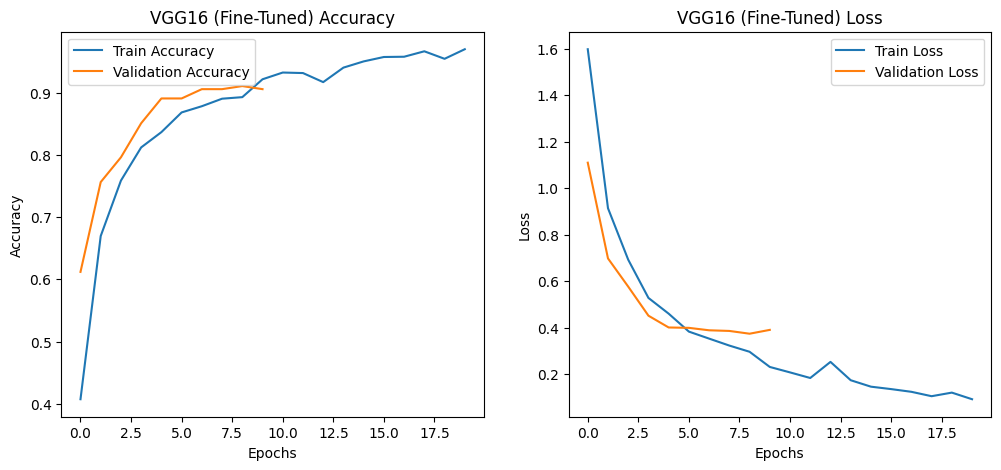

In [9]:
plot_metrics(Vgg16_history_ft, "VGG16 (Fine-Tuned)")

In [10]:
def evaluate_model(model, data_gen):
    predictions = model.predict(data_gen,verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = data_gen.classes

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=data_gen.class_indices.keys()))

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_true, y_pred))

In [11]:
val_gen.reset()
print("\nEvaluating VGG16 Model")
evaluate_model(fine_tuned_model, val_gen)


Evaluating VGG16 Model
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 801ms/step
Classification Report:

                      precision    recall  f1-score   support

         biriani (1)       0.16      0.15      0.16        33
         dimvuna (1)       0.25      0.27      0.26        26
          fuchka (1)       0.21      0.21      0.21        33
        kalavuna (1)       0.17      0.18      0.18        22
        khichuri (1)       0.21      0.23      0.22        40
misti_roshogolla (1)       0.24      0.23      0.23        31
     panta_ilish (1)       0.00      0.00      0.00        16

            accuracy                           0.19       201
           macro avg       0.18      0.18      0.18       201
        weighted avg       0.19      0.19      0.19       201

Confusion Matrix:

[[ 5  2  2  5  8 10  1]
 [ 4  7  1  2  4  3  5]
 [ 7  5  7  5  6  0  3]
 [ 3  2  7  4  4  2  0]
 [ 6  7  7  4  9  6  1]
 [ 3  4  5  2  6  7  4]
 [ 3  1  4  1  6  1  0]]


Trying With different Codes and preprocessed data!!

In [14]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [15]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(224,224,3)
)

In [16]:
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

for layer in conv_base.layers:
  print(layer.name,layer.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [17]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [18]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(7,activation='softmax'))

In [20]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Custom function to add Gaussian noise
def add_gaussian_noise(img, mean=0, std=0.1):
    noise = np.random.normal(mean, std, img.shape)
    noisy_img = np.clip(img + noise, 0, 1)  # Clip to ensure pixel values remain in [0, 1]
    return noisy_img

# Custom DataGenerator with Gaussian noise
class CustomDataGenerator(keras.utils.Sequence):
    def __init__(self, generator, add_noise=False, multiply_times=3):

        self.generator = generator
        self.add_noise = add_noise
        self.multiply_times = multiply_times

    def __len__(self):
        return len(self.generator) * self.multiply_times
    def __getitem__(self, idx):
        batch_x, batch_y = self.generator[idx % len(self.generator)]
        if self.add_noise:
            batch_x = np.array([add_gaussian_noise(img) for img in batch_x])
        return batch_x, batch_y

# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=40  # Add random rotation within the range [-40, 40]
)

# Augmentation for validation
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directory for training and validation
batch_size = 32
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/food classification (1)/Train_png (1)/Train_png (1)',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/food classification (1)/validation_png (1)/validation_png (1)',
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Wrap the train_generator with CustomDataGenerator to add Gaussian noise and multiply data
augmented_train_generator = CustomDataGenerator(
    generator=train_generator,
    add_noise=True,
    multiply_times=3  # Increase training data threefold
)

Found 801 images belonging to 7 classes.
Found 201 images belonging to 7 classes.


In [21]:
def process(image, label):
    label = tf.cast(label, tf.int32)  # Ensure the label is of integer type
    label = tf.one_hot(label, depth=7)  # One-hot encode for 7 classes
    return image, label

# Apply the process function to train and validation datasets
train_ds = augmented_train_generator
validation_ds = validation_generator

In [22]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.3095 - loss: 1.7565 - val_accuracy: 0.6020 - val_loss: 1.0519
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.7308 - loss: 0.8062 - val_accuracy: 0.7463 - val_loss: 0.6876
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8413 - loss: 0.4633 - val_accuracy: 0.7761 - val_loss: 0.6707
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9068 - loss: 0.2856 - val_accuracy: 0.8259 - val_loss: 0.5457
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9203 - loss: 0.2254 - val_accuracy: 0.8408 - val_loss: 0.5456
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9541 - loss: 0.1582 - val_accuracy: 0.8109 - val_loss: 0.6557
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9529 - loss: 0.1494 - val_accuracy: 0.8657 - val_loss: 0.5093
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9783 - loss: 0.0876 - val_accuracy: 0.8458 - v

Overfitted most likely


In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(validation_ds, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Evaluate the model on the training dataset
train_loss, train_accuracy = model.evaluate(train_ds, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")

Validation Loss: 0.5083
Validation Accuracy: 0.8607
Training Loss: 0.0522
Training Accuracy: 0.9892


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step


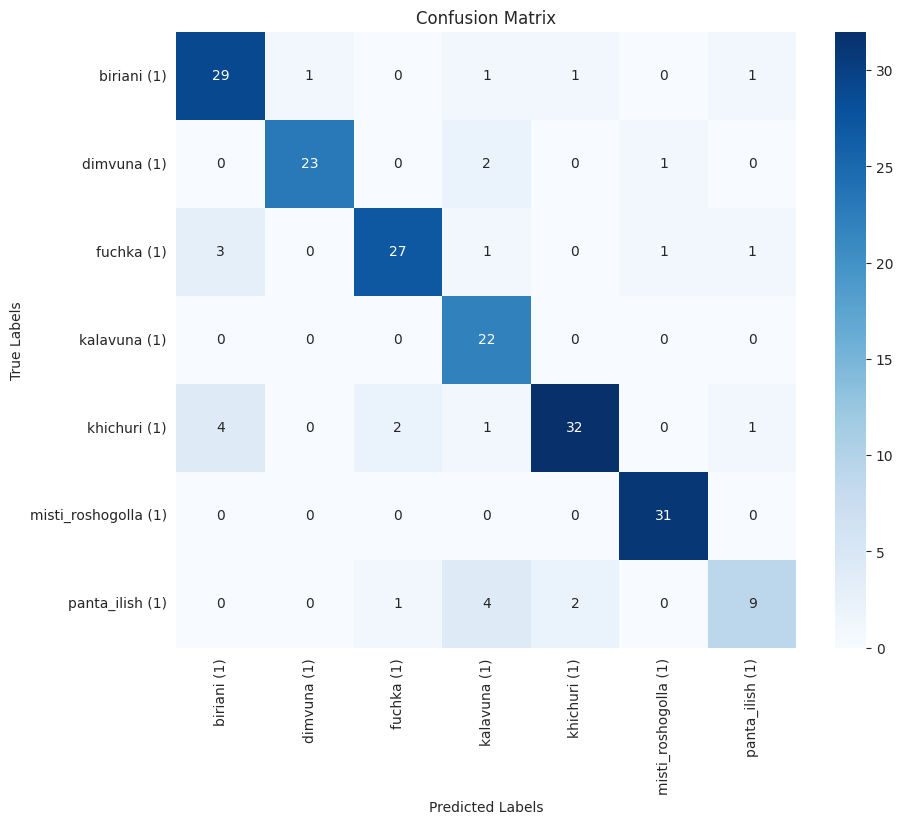

Classification Report:
                      precision    recall  f1-score   support

         biriani (1)     0.8056    0.8788    0.8406        33
         dimvuna (1)     0.9583    0.8846    0.9200        26
          fuchka (1)     0.9000    0.8182    0.8571        33
        kalavuna (1)     0.7097    1.0000    0.8302        22
        khichuri (1)     0.9143    0.8000    0.8533        40
misti_roshogolla (1)     0.9394    1.0000    0.9688        31
     panta_ilish (1)     0.7500    0.5625    0.6429        16

            accuracy                         0.8607       201
           macro avg     0.8539    0.8492    0.8447       201
        weighted avg     0.8682    0.8607    0.8590       201



In [25]:
y_true = []
y_pred = []

# Get predictions and true labels from the test generator
for images, labels in validation_generator:
    # Predict classes for images in the batch
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))  # Predicted class indices
    y_true.extend(np.argmax(labels, axis=1))      # True class indices

    # Break the loop once all samples are processed
    if len(y_true) >= validation_generator.samples:
        break

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(validation_generator.class_indices.keys()),
            yticklabels=list(validation_generator.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
print("Classification Report:")
report = classification_report(
    y_true, y_pred, target_names=list(validation_generator.class_indices.keys()), digits=4
)
print(report)

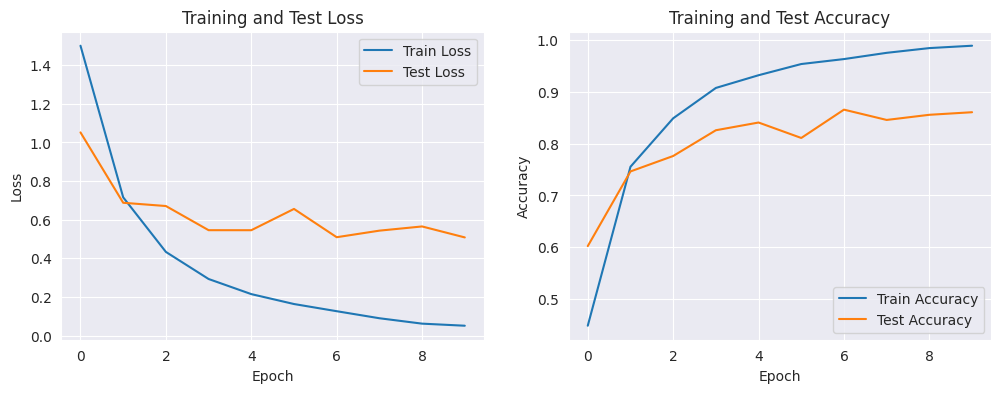

In [26]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')

plt.show()